<a href="https://colab.research.google.com/github/chaitragopalappa/MIE590-690D/blob/main/4_PINN/4a_Nueral_CDE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Overview of Latent Neural ODE and limitations

A Latent ODE frames continuous-time dynamics within an encoder-decoder setup. It encodes all incoming historical time-series data into an initial condition, then allows that state to evolve autonomously in a low-dimensional latent space.

Mechanism: An encoder (such as an RNN or ODE-RNN) processes observations at irregular intervals. It outputs a distribution for the initial latent state z₀.

A decoder then uses an ODE solver to evolve z₀ continuously forward in time.

Core Equation: Governed strictly by an autonomous differential equation: $\frac{dz(t)}{dt} = f_\theta(z(t))$.

Strengths: Excels at generative tasks and data imputation (filling in missing gaps), and outputs an explicit measure of uncertainty (due to the probabilistic VAE framework).

Limitations: Because the ODE trajectory is driven solely by the initial state z₀, later observations cannot directly steer or influence the path without explicitly resetting/updating the state.

### Neural CDE (Controlled Differential Equation)

Neural CDEs remove the need for a separate encoder/decoder by generalizing traditional ODEs to handle continuous, time-varying input signals (called "controls").

Mechanism: Rather than reducing time-series observations to a single starting point, Neural CDEs treat the observed data points as a continuous, interpolated curve (or path) X(t).

The hidden state z(t) is controlled directly by the derivative of this data path.

Core Equation: Governed by a controlled differential equation: $$dz(t) = f_\theta(z(t))dX(t)$$, where dX(t) encapsulates the continuous input data.

The hidden state $z(t)$ then evolves according to

$$ z(t) = z(t_0) + \int_{t_0}^{t} f_\theta(z(s))\, dX(s) $$

This makes it naturally suited to **irregularly-sampled time series** (missed reports,
weekends, irregular testing, etc.) and lets us query the prediction at *any* continuous time,
not just at fixed observation times.

Strengths: Highly expressive for classification and continuous forecasting tasks, as the hidden state instantly responds to incoming data. It avoids the computational overhead of training a VAE's encoder/decoder and variational distributions.

Limitations: Less suited for purely generative tasks, latent-space sampling, or capturing stochastic uncertainty without further extensions (like Neural SDEs)

# PROBLEM SETTING:
SIS epidemic model

With $S(t) + I(t) = 1$ (fractions of a closed population), the SIS dynamics reduce to a single
ODE for the infected fraction $I(t)$:

$$ \frac{dI}{dt} = \beta\, I (1 - I) - \gamma\, I $$
- $\beta$: transmission rate, $\gamma$: recovery rate.
- If $\beta > \gamma$: converges to an **endemic equilibrium** $I^* = 1 - \gamma/\beta$.
- If $\beta \le \gamma$: the epidemic dies out.

## CODE SOURCE:
https://github.com/patrick-kidger/torchcde/blob/master/example/time_series_classification.py
+ AI to modify to SIS epidemic.

Note: this example using equally sampled data and no masking.

In [4]:
# If running in a fresh environment, uncomment to install dependencies:
!pip install torch torchcde torchdiffeq scipy matplotlib numpy

In [9]:
import torch
import torch.nn as nn
import torchcde
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import time

In [ ]:
# GENERATE SYNTHETIC SIS EPIDEMIC DATA
def generate_sis_data(num_samples=100, timesteps=30, beta=0.3, gamma=0.1):
    """
    Generates synthetic SIS trajectories.
    dS/dt = -beta*S*I + gamma*I
    dI/dt =  beta*S*I - gamma*I
    We observe the Infected fraction 'I' over time.
    """
    t = np.linspace(0, 15, timesteps)
    dt = t[1] - t[0]

    all_data = []
    for _ in range(num_samples):
        # Random initial infected fraction between 1% and 10%
        I_val = np.random.uniform(0.01, 0.10)
        S_val = 1.0 - I_val

        trajectory = []
        for step_time_idx in range(timesteps):
            step = t[step_time_idx]
            # Append [time, observed_infected] as our multivariate stream
            trajectory.append([step, I_val])

            # SIS Dynamics
            dS = -beta * S_val * I_val + gamma * I_val
            dI =  beta * S_val * I_val - gamma * I_val

            S_val = np.clip(S_val + dS * dt, 0, 1)
            I_val = np.clip(I_val + dI * dt, 0, 1)

        all_data.append(trajectory)

    return torch.tensor(all_data, dtype=torch.float32)

In [ ]:
# DEFINE THE NEURAL CDE VECTOR FIELD (f_theta)
class CDEFunc(nn.Module):
    def __init__(self, input_channels, hidden_channels):
        super(CDEFunc, self).__init__()
        self.input_channels = input_channels
        self.hidden_channels = hidden_channels

        # Maps hidden state to a matrix of shape (hidden_channels, input_channels)
        self.net = nn.Sequential(
            nn.Linear(hidden_channels, 32),
            nn.ReLU(),
            nn.Linear(32, hidden_channels * input_channels),
            nn.Tanh() # Keeps values bounded for stability
        )

    def forward(self, t, z):
        # z has shape (batch, hidden_channels)
        batch = z.shape[0]
        # Output shape: (batch, hidden_channels, input_channels)
        return self.net(z).view(batch, self.hidden_channels, self.input_channels)

# DEFINE THE NEURAL CDE MODEL ARCHITECTURE
class NeuralCDE(nn.Module):
    def __init__(self, input_channels, hidden_channels, output_channels):
        super(NeuralCDE, self).__init__()

        self.func = CDEFunc(input_channels, hidden_channels)
        # Initial linear map to project initial observation into hidden space
        self.initial_linear = nn.Linear(input_channels, hidden_channels)
        # Readout layer to map the final hidden state to the target epidemic metrics
        self.readout = nn.Linear(hidden_channels, output_channels)

    def forward(self, coeffs):
        # Create a continuous path from the spline coefficients
        X = torchcde.CubicSpline(coeffs)

        # Evaluate initial path value to set up starting hidden condition
        t_start = X.interval[0]
        X_start = X.evaluate(t_start)
        z0 = self.initial_linear(X_start)

        # Solve the Controlled Differential Equation over the time interval
        # dZ/dt = f_theta(Z) * dX/dt
        z_t = torchcde.cdeint(X=X,
                              z0=z0,
                              func=self.func,
                              t=X.interval)

        # Extract the terminal hidden state z_t[:, -1, :]
        # and project it to predict the future epidemic outcome
        final_hidden = z_t[:, -1, :]
        pred = self.readout(final_hidden)
        return pred

In [14]:
# TRAINING & FORECASTING PIPELINE
if __name__ == "__main__":
    # Parameters
    input_channels = 2   # Time t, and Observed Infected fraction I
    hidden_channels = 8  # Latent tracking variables
    output_channels = 5  # Forecasting 5 future infected fractions

    # Define global parameters for data splitting
    total_timesteps = 35 # Generates data up to 35 steps
    context_timesteps = 30 # First 30 steps used as context
    forecast_timesteps = 5 # Predict 5 steps into the future (after context)

    # Generate data (Batch, Timesteps, Channels)
    # Target (y): Predict the infected state for the `forecast_timesteps` into the future
    raw_data = generate_sis_data(num_samples=120, timesteps=total_timesteps)

    # Split historical context (input) and future ground truth (target)
    X_train_raw = raw_data[:100, :context_timesteps, :] # First 30 steps used as context
    # Target: I for steps from context_timesteps up to (context_timesteps + forecast_timesteps)
    y_train = raw_data[:100, context_timesteps:(context_timesteps + forecast_timesteps), 1]

    X_val_raw = raw_data[100:, :context_timesteps, :]
    y_val = raw_data[100:, context_timesteps:(context_timesteps + forecast_timesteps), 1]

    # Compute Natural Cubic Spline coefficients to make input paths continuous
    train_coeffs = torchcde.natural_cubic_spline_coeffs(X_train_raw)
    val_coeffs = torchcde.natural_cubic_spline_coeffs(X_val_raw)

    # Model configuration
    model = NeuralCDE(input_channels, hidden_channels, output_channels)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.MSELoss()

    # Training Loop
    print("Beginning Training...")

    for epoch in range(1, 1000):
        model.train()
        optimizer.zero_grad()

        # Forward pass through the CDE solver
        predictions = model(train_coeffs)
        loss = criterion(predictions, y_train)

        loss.backward()
        optimizer.step()

        if epoch % 20 == 0 or epoch == 1:
            # Validation Check
            model.eval()
            with torch.no_grad():
                val_preds = model(val_coeffs)
                val_loss = criterion(val_preds, y_val)
            print(f"Epoch {epoch:03d} | Train MSE Loss: {loss.item():.6f} | Val MSE Loss: {val_loss.item():.6f}")

    print("\nTraining Complete. Model is ready for real-time SIS epidemic forecasting!")

Beginning Training...
Epoch 001 | Train MSE Loss: 1.299625 | Val MSE Loss: 2.549424
Epoch 020 | Train MSE Loss: 0.092578 | Val MSE Loss: 0.084790
Epoch 040 | Train MSE Loss: 0.014993 | Val MSE Loss: 0.010948
Epoch 060 | Train MSE Loss: 0.011744 | Val MSE Loss: 0.006557
Epoch 080 | Train MSE Loss: 0.011070 | Val MSE Loss: 0.006773
Epoch 100 | Train MSE Loss: 0.010930 | Val MSE Loss: 0.006565
Epoch 120 | Train MSE Loss: 0.010762 | Val MSE Loss: 0.006387
Epoch 140 | Train MSE Loss: 0.010325 | Val MSE Loss: 0.006061
Epoch 160 | Train MSE Loss: 0.008937 | Val MSE Loss: 0.004760
Epoch 180 | Train MSE Loss: 0.017394 | Val MSE Loss: 0.010334
Epoch 200 | Train MSE Loss: 0.006173 | Val MSE Loss: 0.003315
Epoch 220 | Train MSE Loss: 0.001857 | Val MSE Loss: 0.001083
Epoch 240 | Train MSE Loss: 0.000834 | Val MSE Loss: 0.000468
Epoch 260 | Train MSE Loss: 0.000590 | Val MSE Loss: 0.000330
Epoch 280 | Train MSE Loss: 0.000458 | Val MSE Loss: 0.000269
Epoch 300 | Train MSE Loss: 0.000835 | Val MSE L

(20, 5)


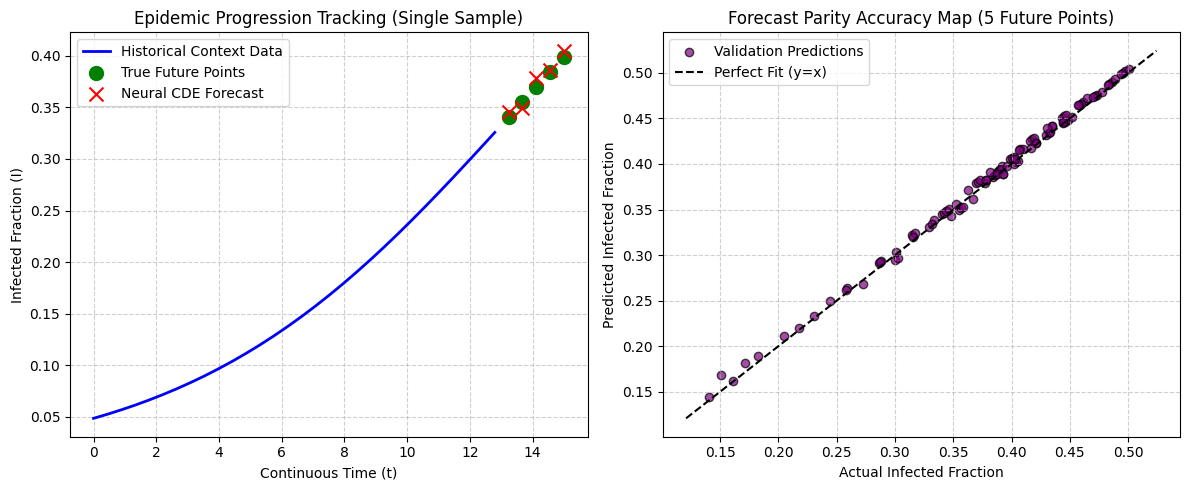

In [17]:
# VISUALIZATION MODULE
num_plots=3
model.eval()
with torch.no_grad():
    # Generate neural predictions for validation cases
    predictions_tensor = model(val_coeffs)
    actuals_tensor = y_val

    val_loss = criterion(predictions_tensor, actuals_tensor)

    predictions = predictions_tensor.cpu().numpy()
    actuals = actuals_tensor.cpu().numpy()

print(np.shape(predictions))
plt.figure(figsize=(12, 5))

# Define parameters for times (consistent with training data generation)
total_timesteps = 35
context_timesteps = 30
forecast_timesteps = 5
all_times_generated = np.linspace(0, 15, total_timesteps)
historical_times_plot = all_times_generated[:context_timesteps]
future_times_plot = all_times_generated[context_timesteps:(context_timesteps + forecast_timesteps)]

# 1. Trajectory Timeline View (Sample #0)
plt.subplot(1, 2, 1)

# Plot historical trajectory feeding into the Neural CDE
time_hist = X_val_raw[0, :, 0].cpu().numpy()
inf_hist = X_val_raw[0, :, 1].cpu().numpy()
plt.plot(time_hist, inf_hist, label="Historical Context Data", color="blue", lw=2)

# Plot the true future points (5 points)
plt.scatter(future_times_plot, actuals[0], color="green", marker="o", s=100, label="True Future Points", zorder=5)
# Plot the predicted future points (5 points)
plt.scatter(future_times_plot, predictions[0], color="red", marker="x", s=100, label="Neural CDE Forecast", zorder=5)

plt.title("Epidemic Progression Tracking (Single Sample)")
plt.xlabel("Continuous Time (t)")
plt.ylabel("Infected Fraction (I)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

# 2. Parity Scatter View (All Validation Samples)
plt.subplot(1, 2, 2)

# Flatten actuals and predictions for the parity plot
flat_actuals = actuals.flatten()
flat_predictions = predictions.flatten()

min_val = min(flat_actuals.min(), flat_predictions.min()) - 0.02
max_val = max(flat_actuals.max(), flat_predictions.max()) + 0.02

plt.scatter(flat_actuals, flat_predictions, color="purple", alpha=0.7, edgecolors='k', label="Validation Predictions")
plt.plot([min_val, max_val], [min_val, max_val], color="black", linestyle="--", label="Perfect Fit (y=x)")

plt.title("Forecast Parity Accuracy Map (5 Future Points)")
plt.xlabel("Actual Infected Fraction")
plt.ylabel("Predicted Infected Fraction")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

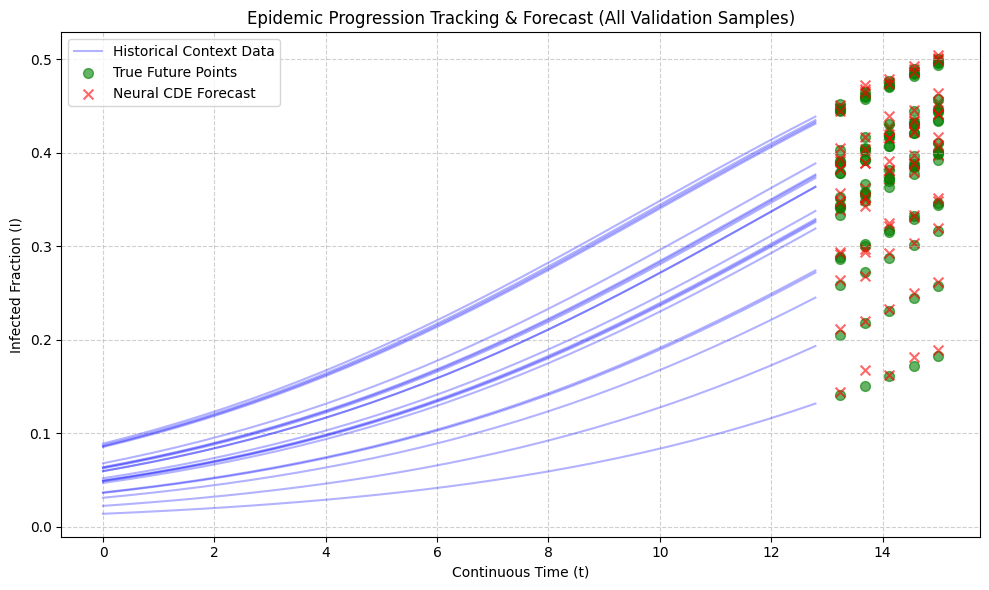

In [18]:
# Plot all validation trajectories
plt.figure(figsize=(10, 6))

# Define parameters for times (consistent with training data generation)
total_timesteps = 35
context_timesteps = 30
forecast_timesteps = 5
all_times_generated = np.linspace(0, 15, total_timesteps)
historical_times_plot = all_times_generated[:context_timesteps]
future_times_plot = all_times_generated[context_timesteps:(context_timesteps + forecast_timesteps)]

for i in range(len(X_val_raw)):
    # Historical context data
    time_hist = X_val_raw[i, :, 0].cpu().numpy()
    inf_hist = X_val_raw[i, :, 1].cpu().numpy()
    plt.plot(time_hist, inf_hist, color='blue', alpha=0.3, label='_nolegend_' if i > 0 else 'Historical Context Data')

    # True future points (5 points)
    # y_val[i] has shape (5)
    plt.scatter(future_times_plot, y_val[i].cpu().numpy(), color='green', marker='o', s=50, alpha=0.6, label='_nolegend_' if i > 0 else 'True Future Points')

    # Neural CDE forecast (5 points)
    # predictions[i] has shape (5)
    plt.scatter(future_times_plot, predictions[i], color='red', marker='x', s=50, alpha=0.6, label='_nolegend_' if i > 0 else 'Neural CDE Forecast')

plt.title("Epidemic Progression Tracking & Forecast (All Validation Samples)")
plt.xlabel("Continuous Time (t)")
plt.ylabel("Infected Fraction (I)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()